# IV.2.2 — Spatial Characteristic Analysis of BISINDO Skeleton Data

This notebook generates visualizations to document **spatial issues/characteristics** found in the BISINDO skeleton data before pre-processing.

Three analysis groups:
1. **IV.2.2.1 — Position and Scale Variations Across Signers** → Scatter overlay, keypoint distance boxplot, multi-signer skeleton overlay
2. **IV.2.2.2 — Inter-frame Coordinate Instability (Micro-shift)** → Coordinate fluctuation line chart, displacement histogram
3. **IV.2.2.3 — [0,0] Coordinate Noise** → Noise frequency heatmap per keypoint, noise bar chart per signer, frame visualization with noise

---

In [32]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
from collections import defaultdict
import os

# ── Paper-style global rcParams (consistent with reference notebooks) ─────────
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.edgecolor'     : '#333333',
    'axes.linewidth'     : 0.8,
    'axes.grid'          : False,
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 10,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 9,
    'figure.titlesize'   : 11,
    'figure.titleweight' : 'bold',
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.05,
})

# ── Color palette ─────────────────────────────────────────────────────────────
C_LH     = '#2166AC'   # Left hand  – deep blue
C_RH     = '#D6604D'   # Right hand – muted red
C_EDGE   = '#555555'   # Skeleton edges
C_NOISE  = '#B2182B'   # Noise highlight – red
C_VALID  = '#4393C3'   # Valid keypoint
GRAYS    = ['#1a1a1a', '#555555', '#888888', '#bbbbbb']
BAR_EC   = 'black'
BAR_LW   = 0.6

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = '../data/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hand skeleton edges ───────────────────────────────────────────────────────
HAND_EDGES = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]
CONNECTIONS = [(u,v) for u,v in HAND_EDGES] + [(u+21,v+21) for u,v in HAND_EDGES]

IDX_LH   = np.arange(0, 21)    # Left hand
IDX_RH   = np.arange(21, 42)   # Right hand
IDX_HAND = np.arange(0, 42)    # Both hands

print('Configuration loaded.')

Configuration loaded.


## 0. Load Data

In [33]:
# ── CONFIGURATION — adjust path to your directory structure ─────────────
PICKLE_FILE = '../data/pickle/pose_bisindo.pkl'

with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

video_ids = list(data.keys())
print(f'Total videos : {len(video_ids)}')
print(f'Sample IDs   : {video_ids[:5]}')

# Extract signer info from video ID (format: Pxx_Sxxx_Rxx)
speakers = sorted(set(v.split('_')[0] for v in video_ids))
print(f'Signers      : {speakers}')

# Keypoint layout (86 points):
# [0:21]  = Left Hand  (21 pts)
# [21:42] = Right Hand (21 pts)
# [42:61] = Mouth      (19 pts)
# [61:86] = Pose/Body  (25 pts)
K_TOTAL = 86

Total videos : 807
Sample IDs   : ['P1_S01_R1', 'P1_S01_R2', 'P1_S01_R3', 'P1_S01_R4', 'P1_S01_R5']
Signers      : ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']


---
## IV.2.2.1 — Position and Scale Variations Across Signers

Three visualizations:
- **Fig A** — Hand coordinate scatter plot overlay for all signers (raw, before normalization)
- **Fig B** — Wrist → middle finger tip distance boxplot per signer (hand scale variation)
- **Fig C** — Skeleton visualization overlay of several signers in a single frame

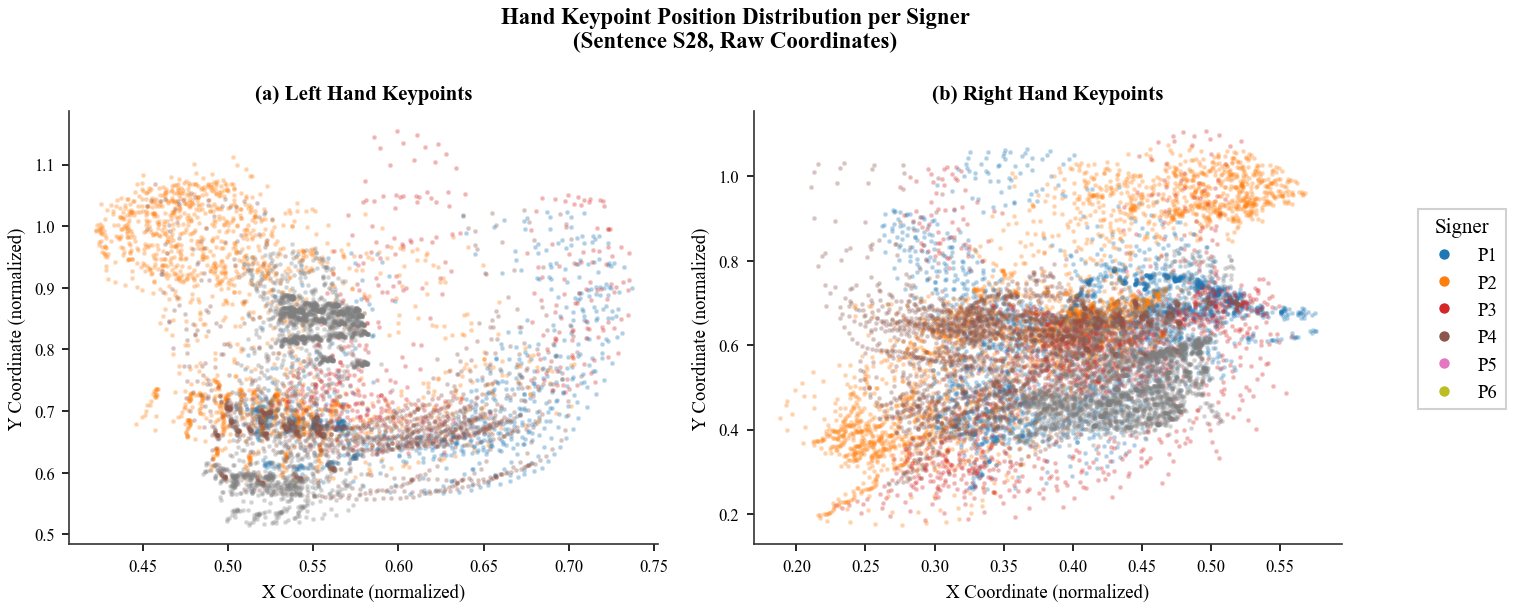

[SAVED] ../data/results\spatial_A_same_sentence_scatter.png


In [34]:
# ── Fig A: Hand Coordinate Scatter Overlay (Same Sentence Across Signers) ────
# Purpose:
# Show inter-signer spatial variation using the SAME sentence only.

# ── CONFIGURATION ─────────────────────────────────────────────────────────────

TARGET_SEQUENCE = 'S28'
TARGET_REP      = 'R1'

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=150)

titles = ['(a) Left Hand Keypoints', '(b) Right Hand Keypoints']
idx_parts = [IDX_LH, IDX_RH]

colors_sp = plt.cm.tab10(np.linspace(0, 0.9, len(speakers)))

# ──────────────────────────────────────────────────────────────────────────────

for ax, idx_part, title in zip(axes, idx_parts, titles):

    for sp, color in zip(speakers, colors_sp):

        # Same sentence + same repetition
        sp_vids = sorted([
            v for v in video_ids
            if v.startswith(sp)
            and TARGET_SEQUENCE in v
            and f'_{TARGET_REP}' in v
        ])

        if not sp_vids:
            continue

        # Use only one video per signer
        vid = sp_vids[0]

        kp = data[vid]['keypoints']   # (T, K, 2)

        pts = kp[:, idx_part, :]      # (T, 21, 2)

        # Remove [0,0]
        valid = ~(
            (pts[:,:,0] == 0) &
            (pts[:,:,1] == 0)
        )

        xs = pts[:,:,0][valid]
        ys = pts[:,:,1][valid]

        ax.scatter(
            xs,
            ys,
            s=2,
            alpha=0.22,
            color=color,
            label=sp,
            rasterized=True
        )

    # ── Axis Style ────────────────────────────────────────────────────────────

    ax.set_title(title)

    ax.set_xlabel('X Coordinate (normalized)')
    ax.set_ylabel('Y Coordinate (normalized)')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────

handles = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=plt.cm.tab10(i / len(speakers)),
        markersize=6,
        label=sp
    )

    for i, sp in enumerate(speakers)
]

fig.legend(
    handles=handles,
    title='Signer',
    loc='center right',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    fancybox=False
)

# ── Title ─────────────────────────────────────────────────────────────────────

plt.suptitle(
    f'Hand Keypoint Position Distribution per Signer\n'
    f'(Sentence {TARGET_SEQUENCE}, Raw Coordinates)',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 0.92, 1])

# ── Save ──────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_A_same_sentence_scatter.png'
)

plt.savefig(save_path)

plt.show()

print(f'[SAVED] {save_path}')

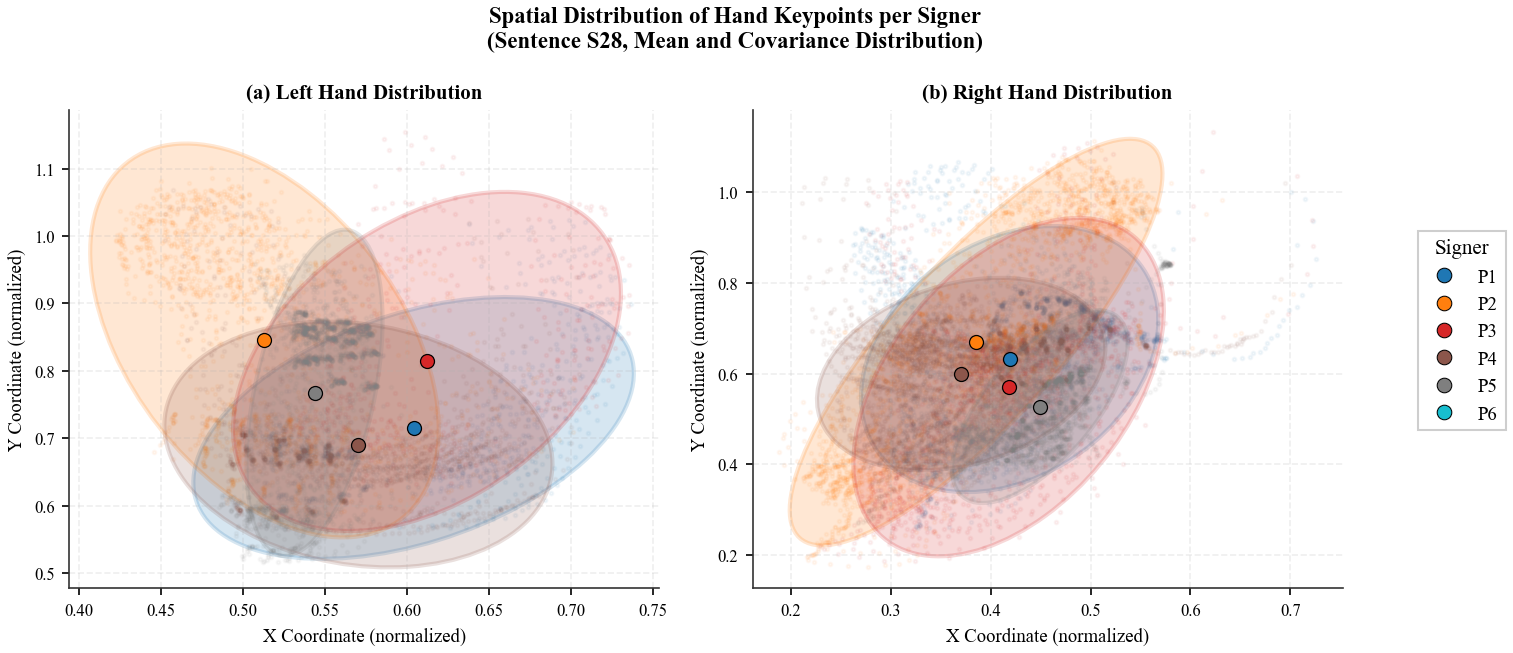

[SAVED] ../data/results\spatial_A_covariance_ellipse.png


In [35]:
# ── Fig A: Signer Spatial Distribution using Mean + Covariance Ellipse ───────
# Purpose:
# Show inter-signer spatial variation more clearly than dense scatter plots.

import os
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

# ── CONFIGURATION ─────────────────────────────────────────────────────────────

TARGET_SEQUENCE = 'S28'
TARGET_REP      = 'R1'

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), dpi=150)
# Left hand keypoint indices
IDX_LH = list(range(0, 20))   # 21 keypoints

# Right hand keypoint indices
IDX_RH = list(range(20, 41))  # 21 keypoints
titles = ['(a) Left Hand Distribution', '(b) Right Hand Distribution']
idx_parts = [IDX_LH, IDX_RH]

colors_sp = plt.cm.tab10(np.linspace(0, 0.9, len(speakers)))

# ── Helper Function: Covariance Ellipse ──────────────────────────────────────

def draw_cov_ellipse(ax, xs, ys, color, n_std=2.0):

    if len(xs) < 2:
        return

    cov = np.cov(xs, ys)

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]

    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(
        np.arctan2(*vecs[:, 0][::-1])
    )

    width, height = 2 * n_std * np.sqrt(vals)

    mean_x = np.mean(xs)
    mean_y = np.mean(ys)

    ellipse = Ellipse(
        (mean_x, mean_y),
        width=width,
        height=height,
        angle=theta,
        edgecolor=color,
        facecolor=color,
        lw=2,
        alpha=0.18
    )

    ax.add_patch(ellipse)

    # Centroid
    ax.scatter(
        mean_x,
        mean_y,
        color=color,
        s=45,
        edgecolor='black',
        linewidth=0.6,
        zorder=5
    )

# ──────────────────────────────────────────────────────────────────────────────

for ax, idx_part, title in zip(axes, idx_parts, titles):

    for sp, color in zip(speakers, colors_sp):

        # Same sentence + same repetition
        sp_vids = sorted([
            v for v in video_ids
            if v.startswith(sp)
            and TARGET_SEQUENCE in v
            and f'_{TARGET_REP}' in v
        ])

        if not sp_vids:
            continue

        # Use only one video per signer
        vid = sp_vids[0]

        kp = data[vid]['keypoints']   # (T, K, 2)

        pts = kp[:, idx_part, :]      # (T, 21, 2)

        # Remove invalid points [0,0]
        valid = ~(
            (pts[:, :, 0] == 0) &
            (pts[:, :, 1] == 0)
        )

        xs = pts[:, :, 0][valid]
        ys = pts[:, :, 1][valid]

        # Optional: small transparent scatter for context
        ax.scatter(
            xs,
            ys,
            s=3,
            alpha=0.05,
            color=color,
            rasterized=True
        )

        # Draw covariance ellipse + centroid
        draw_cov_ellipse(
            ax,
            xs,
            ys,
            color=color,
            n_std=2.0
        )

    # ── Axis Style ────────────────────────────────────────────────────────────

    ax.set_title(
        title,
        fontsize=10,
        fontweight='bold'
    )

    ax.set_xlabel('X Coordinate (normalized)')
    ax.set_ylabel('Y Coordinate (normalized)')

    ax.grid(
        alpha=0.2,
        linestyle='--'
    )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────

handles = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color,
        markeredgecolor='black',
        markeredgewidth=0.5,
        markersize=7,
        label=sp
    )

    for sp, color in zip(speakers, colors_sp)
]

fig.legend(
    handles=handles,
    title='Signer',
    loc='center right',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    framealpha=0.95,
    edgecolor='#cccccc',
    fancybox=False
)

# ── Main Title ────────────────────────────────────────────────────────────────

plt.suptitle(
    f'Spatial Distribution of Hand Keypoints per Signer\n'
    f'(Sentence {TARGET_SEQUENCE}, Mean and Covariance Distribution)',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 0.92, 1])

# ── Save ──────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_A_covariance_ellipse.png'
)

plt.savefig(
    save_path,
    bbox_inches='tight'
)

plt.show()

print(f'[SAVED] {save_path}')

---
### Fig A2 — Wrist Position Boxplot per Signer (Full Dataset)

**Purpose:** Quantify inter-signer positional variation using the **wrist keypoint** (index 0 = LH wrist, index 21 = RH wrist) across **all videos and sentences** in the dataset.  
This directly justifies wrist-anchored spatial normalization in IV.4.1: if wrist positions differ systematically across signers, all downstream keypoints inherit that offset.

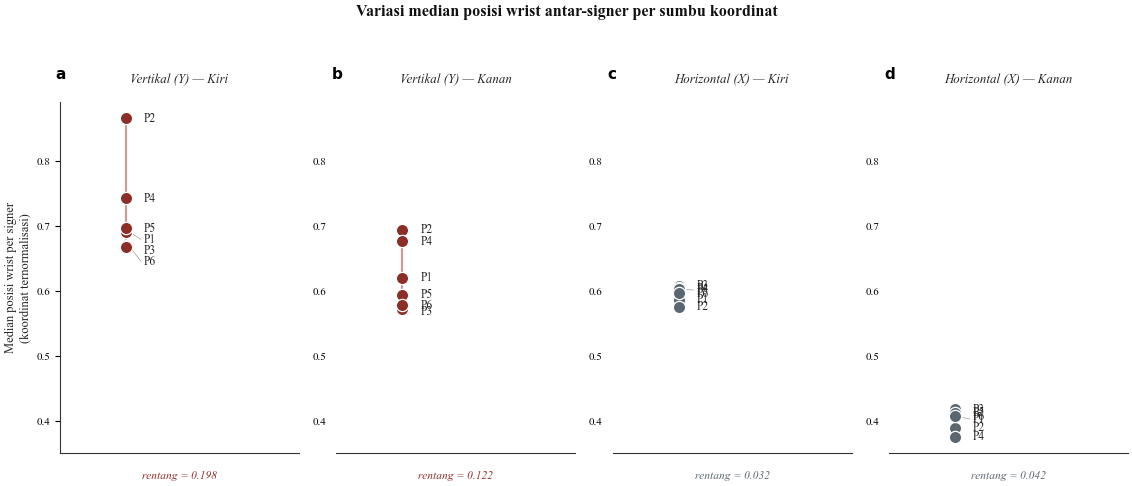

[SAVED] ../data/results\spatial_A2_wrist_signer_dotplot_q1.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import numpy as np
from collections import defaultdict

# ── 1. Aggregation of Data ────────────────────────────────────────────────────
# Collect all valid wrist coordinates for each signer across ALL videos
lh_y = defaultdict(list)
lh_x = defaultdict(list)
rh_y = defaultdict(list)
rh_x = defaultdict(list)

WRIST_LH = 0
WRIST_RH = 21

for vid in video_ids:
    sp = vid.split('_')[0]
    kp = data[vid]['keypoints']
    
    # Left Wrist
    w_l = kp[:, WRIST_LH, :]
    valid_l = ~( (w_l[:, 0] == 0) & (w_l[:, 1] == 0) )
    lh_x[sp].extend(w_l[valid_l, 0].tolist())
    lh_y[sp].extend(w_l[valid_l, 1].tolist())
    
    # Right Wrist
    w_r = kp[:, WRIST_RH, :]
    valid_r = ~( (w_r[:, 0] == 0) & (w_r[:, 1] == 0) )
    rh_x[sp].extend(w_r[valid_r, 0].tolist())
    rh_y[sp].extend(w_r[valid_r, 1].tolist())

signer_labels = speakers
vals_lh_y = [np.median(lh_y[sp]) for sp in speakers]
vals_rh_y = [np.median(rh_y[sp]) for sp in speakers]
vals_lh_x = [np.median(lh_x[sp]) for sp in speakers]
vals_rh_x = [np.median(rh_x[sp]) for sp in speakers]

spread_lh_y = max(vals_lh_y) - min(vals_lh_y)
spread_rh_y = max(vals_rh_y) - min(vals_rh_y)
spread_lh_x = max(vals_lh_x) - min(vals_lh_x)
spread_rh_x = max(vals_rh_x) - min(vals_rh_x)

# ── Academic (Q1-journal) styling ─────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Georgia'],
    'mathtext.fontset': 'cm',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'font.size': 9,
})

# Palet muted, khas figur jurnal (bukan warna saturasi tinggi)
C_VERTICAL   = '#8C2D27'   # merah bata gelap, desaturasi
C_HORIZONTAL = '#5B6770'   # abu kebiruan gelap, desaturasi
C_LINE_V     = '#C99C95'   # garis penghubung vertikal, muted
C_LINE_H     = '#B6BEC3'   # garis penghubung horizontal, muted

panels = [
    {'tag': 'a', 'title': 'Vertikal (Y) — Kiri',  'vals': vals_lh_y, 'color': C_VERTICAL,   'line': C_LINE_V, 'spread': spread_lh_y},
    {'tag': 'b', 'title': 'Vertikal (Y) — Kanan', 'vals': vals_rh_y, 'color': C_VERTICAL,   'line': C_LINE_V, 'spread': spread_rh_y},
    {'tag': 'c', 'title': 'Horizontal (X) — Kiri','vals': vals_lh_x, 'color': C_HORIZONTAL, 'line': C_LINE_H, 'spread': spread_lh_x},
    {'tag': 'd', 'title': 'Horizontal (X) — Kanan','vals': vals_rh_x, 'color': C_HORIZONTAL,'line': C_LINE_H, 'spread': spread_rh_x},
]

# Global Y scale untuk semua panel
all_vals = (
    vals_lh_y +
    vals_rh_y +
    vals_lh_x +
    vals_rh_x
)

global_min = min(all_vals)
global_max = max(all_vals)

global_pad = (global_max - global_min) * 0.05

fig, axes = plt.subplots(1, 4, figsize=(11.5, 5.0))

for idx, (ax, panel) in enumerate(zip(axes, panels)):
    vals = panel['vals']
    col = panel['color']
    line_col = panel['line']
    order = sorted(range(len(vals)), key=lambda i: vals[i], reverse=True)

    y_min, y_max = min(vals), max(vals)
    local_range = y_max - y_min

    ax.plot([0, 0], [y_min, y_max], color=line_col, linewidth=1.6, zorder=1, solid_capstyle='round')
    ax.scatter([0]*len(vals), vals, facecolor=col, edgecolor='white', linewidth=0.9, s=78, zorder=3)

    # anti-overlap label
    close_thresh = (y_max - y_min) * 0.085 if y_max > y_min else 0.01
    label_y_list = []
    for rank, i in enumerate(order):
        v = vals[i]
        ly = v if rank == 0 else min(v, label_y_list[-1] - close_thresh)
        label_y_list.append(ly)

    for i, ly in zip(order, label_y_list):
        v = vals[i]
        ax.annotate(signer_labels[i], xy=(0, v), xytext=(0.11, ly),
                    textcoords='data', fontsize=8.3, va='center', ha='left', color='#222222')
        if abs(ly - v) > close_thresh * 0.4:
            ax.plot([0.025, 0.09], [v, ly], color='#999999', linewidth=0.5, zorder=2)

    ax.set_xlim(-0.4, 1.05)
    ax.set_ylim(
        global_min - global_pad,
        global_max + global_pad
    )
    ax.set_xticks([])

    # Panel tag (gaya Nature/IEEE: huruf tebal kecil pojok kiri-atas)
    ax.text(-0.02, 1.06, panel['tag'], transform=ax.transAxes, fontsize=11,
            fontweight='bold', ha='left', va='bottom', fontfamily='sans-serif')
    ax.set_title(panel['title'], fontsize=9.3, fontweight='normal', color='#222222',
                 pad=14, loc='center', style='italic')

    ax.text(0.5, -0.075, f"rentang = {panel['spread']:.3f}", transform=ax.transAxes,
            ha='center', fontsize=8.3, color=col, fontstyle='italic')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # tampilkan sumbu Y pada semua panel
    ax.spines['left'].set_visible(True)

    ax.tick_params(
        axis='y',
        labelsize=8,
        left=True
    )
    ax.tick_params(labelsize=8)

    ax.grid(
        axis='y',
        linestyle=':',
        linewidth=0.5,
        alpha=0.4
    )

    if idx == 0:
        ax.set_ylabel('Median posisi wrist per signer\n(koordinat ternormalisasi)',
                       fontsize=9, color='#222222')

fig.suptitle(
    'Variasi median posisi wrist antar-signer per sumbu koordinat',
    fontsize=11.5, fontweight='bold', y=1.005, color='#111111'
)

plt.tight_layout(rect=[0, 0.02, 1, 0.97])

save_path = os.path.join(OUTPUT_DIR, 'spatial_A2_wrist_signer_dotplot_q1.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()
print(f'[SAVED] {save_path}')


---
### Fig A3 — Inter-Signer Wrist Distance Heatmap (All Sentences)

**Purpose:** Quantify *how far apart* each pair of signers is in wrist coordinate space, averaged across all 30 sentences.  
If pairwise distances are consistently large across all sentence combinations, this confirms that positional divergence is a **systematic dataset-level problem**, not an artifact of a single sentence.  
Directly motivates the wrist-anchored normalization in IV.4.1.

In [ ]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import os

# ── Compute Pairwise Euclidean Distance Matrix of Median Coordinates ────────────
dist_lh = pd.DataFrame(index=speakers, columns=speakers, dtype=float)
dist_rh = pd.DataFrame(index=speakers, columns=speakers, dtype=float)

for u in speakers:
    for v in speakers:
        if u == v:
            dist_lh.loc[u, v] = 0.0
            dist_rh.loc[u, v] = 0.0
        else:
            u_pt_l = np.array([vals_lh_x[speakers.index(u)], vals_lh_y[speakers.index(u)]])
            v_pt_l = np.array([vals_lh_x[speakers.index(v)], vals_lh_y[speakers.index(v)]])
            dist_lh.loc[u, v] = np.linalg.norm(u_pt_l - v_pt_l)
            
            u_pt_r = np.array([vals_rh_x[speakers.index(u)], vals_rh_y[speakers.index(u)]])
            v_pt_r = np.array([vals_rh_x[speakers.index(v)], vals_rh_y[speakers.index(v)]])
            dist_rh.loc[u, v] = np.linalg.norm(u_pt_r - v_pt_r)

# ── Horizontal Bar Chart: Inter-Signer Wrist Distance ─────────────────────────

pairs = list(itertools.combinations(speakers, 2))
pair_labels = [f'{u}–{v}' for u, v in pairs]

lh_values = [dist_lh.loc[u, v] for u, v in pairs]
rh_values = [dist_rh.loc[u, v] for u, v in pairs]

lh_sorted = sorted(zip(pair_labels, lh_values), key=lambda x: x[1])
lh_labels = [x[0] for x in lh_sorted]
lh_vals = [x[1] for x in lh_sorted]

rh_sorted = sorted(zip(pair_labels, rh_values), key=lambda x: x[1])
rh_labels = [x[0] for x in rh_sorted]
rh_vals = [x[1] for x in rh_sorted]

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharex=True)

# LH Bar Chart
axes[0].barh(lh_labels, lh_vals, color=C_LH, edgecolor='black', linewidth=1, alpha=0.85)
axes[0].set_title('Tangan Kiri', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Rata-rata Jarak Euclidean', fontsize=9)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

for i, v in enumerate(lh_vals):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

# RH Bar Chart
axes[1].barh(rh_labels, rh_vals, color=C_RH, edgecolor='black', linewidth=1, alpha=0.85)
axes[1].set_title('Tangan Kanan', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Rata-rata Jarak Euclidean', fontsize=9)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

for i, v in enumerate(rh_vals):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle(
    'Jarak Pergelangan Tangan Antar-Signer (Rata-rata Seluruh Kalimat)\n'
    '(Diurutkan berdasarkan jarak untuk menonjolkan pasangan signer paling divergen)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

save_path = os.path.join(OUTPUT_DIR, 'spatial_A3_intersigner_wrist_barchart.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'[SAVED] {save_path}')
